# Bleaching Analysis + Carbonate Chemistry (Atlantic)

This notebook follows the modeling workflow in `bleaching_analysis.ipynb` and adds a nearest spatial-temporal match from `Carbonate_Chemistry_Atlantic_Cleaned.csv` to the bleaching datapoints.


In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GroupShuffleSplit
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor

pd.set_option("display.max_columns", 200)
np.random.seed(42)


In [23]:
BLEACH_PATH = "../../data/processed/NOAA/NOAA_Global_Bleaching_Cleaned.csv"
CARBONATE_PATH = "../../data/processed/CORIS_DATA/ATLANTIC/Carbonate_Chemistry_Atlantic_Cleaned.csv"

bleach_raw = pd.read_csv(BLEACH_PATH, low_memory=False)
carb_raw = pd.read_csv(CARBONATE_PATH, low_memory=False)

print("Bleaching raw shape:", bleach_raw.shape)
print("Carbonate raw shape:", carb_raw.shape)


Bleaching raw shape: (41361, 48)
Carbonate raw shape: (5017, 13)


In [24]:
bleach = bleach_raw.copy()
carb = carb_raw.copy()

bleach.columns = [c.strip() for c in bleach.columns]
carb.columns = [c.strip() for c in carb.columns]

if "Percent Bleaching" in bleach.columns and "Percent_Bleaching" not in bleach.columns:
    bleach = bleach.rename(columns={"Percent Bleaching": "Percent_Bleaching"})

for col in ["Latitude_Degrees", "Longitude_Degrees", "Percent_Bleaching"]:
    if col in bleach.columns:
        bleach[col] = pd.to_numeric(bleach[col], errors="coerce")

carbonate_feature_cols = [
    "Dissolved_Inorganic_Carbon_MICRO_MOL_KG",
    "Total_Alkalinity_MICRO_MOL_KG",
    "pH_measured",
    "pH_calculated",
    "pCO2",
    "Aragonite_Saturation_State",
    "Salinity_Bottle",
    "Temperature_C",
]
for col in ["latitude", "longitude"] + carbonate_feature_cols:
    if col in carb.columns:
        carb[col] = pd.to_numeric(carb[col], errors="coerce")

bleach["Date"] = pd.to_datetime(bleach["Date"], errors="coerce")
carb["time"] = pd.to_datetime(carb["time"], errors="coerce", utc=True).dt.tz_convert(None)

bleach = bleach[bleach["Ocean_Name"].astype(str).str.lower() == "atlantic"].copy()
bleach = bleach.dropna(subset=["Latitude_Degrees", "Longitude_Degrees", "Date"])
carb = carb.dropna(subset=["latitude", "longitude", "time"]).copy()

print("Atlantic bleaching rows with valid coords/date:", len(bleach))
print("Carbonate rows with valid coords/time:", len(carb))


Atlantic bleaching rows with valid coords/date: 14592
Carbonate rows with valid coords/time: 5016


/var/folders/25/4sydytjj5kx7w08vfts5w61r0000gn/T/ipykernel_96711/3968675115.py:29: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  carb["time"] = pd.to_datetime(carb["time"], errors="coerce", utc=True).dt.tz_convert(None)


In [25]:
def haversine_km(lat1, lon1, lat2, lon2):
    r_km = 6371.0
    lat1 = np.radians(lat1)
    lon1 = np.radians(lon1)
    lat2 = np.radians(lat2)
    lon2 = np.radians(lon2)
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat / 2.0) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2.0) ** 2
    return 2.0 * r_km * np.arcsin(np.sqrt(a))


def match_carbonate_to_bleaching(bleach_df, carb_df, max_days=45, max_km=50, bbox_deg=1.0):
    left = bleach_df.reset_index(drop=True).copy()
    left["bleach_row_id"] = np.arange(len(left))
    left["match_year"] = left["Date"].dt.year

    right = carb_df.reset_index(drop=True).copy()
    right["match_year"] = right["time"].dt.year

    overlap_years = sorted(set(left["match_year"].dropna().astype(int)).intersection(set(right["match_year"].dropna().astype(int))))
    matches = []

    for year in overlap_years:
        b_year = left[left["match_year"] == year]
        c_year = right[right["match_year"] == year]
        if b_year.empty or c_year.empty:
            continue

        c_time = c_year["time"].to_numpy(dtype="datetime64[ns]")

        for row in b_year.itertuples(index=False):
            t0 = np.datetime64(row.Date - pd.Timedelta(days=max_days))
            t1 = np.datetime64(row.Date + pd.Timedelta(days=max_days))
            time_mask = (c_time >= t0) & (c_time <= t1)
            if not time_mask.any():
                continue

            cand = c_year.loc[time_mask].copy()
            cand = cand[
                cand["latitude"].between(row.Latitude_Degrees - bbox_deg, row.Latitude_Degrees + bbox_deg)
                & cand["longitude"].between(row.Longitude_Degrees - bbox_deg, row.Longitude_Degrees + bbox_deg)
            ]
            if cand.empty:
                continue

            cand["match_distance_km"] = haversine_km(
                row.Latitude_Degrees,
                row.Longitude_Degrees,
                cand["latitude"].to_numpy(),
                cand["longitude"].to_numpy(),
            )
            cand = cand[cand["match_distance_km"] <= max_km]
            if cand.empty:
                continue

            cand["match_delta_days"] = (cand["time"] - row.Date).abs() / pd.Timedelta(days=1)
            best = cand.sort_values(["match_distance_km", "match_delta_days"]).iloc[0]

            record = {
                "bleach_row_id": row.bleach_row_id,
                "carbonate_match_found": 1,
                "match_distance_km": float(best["match_distance_km"]),
                "match_delta_days": float(best["match_delta_days"]),
            }
            for col in carbonate_feature_cols:
                record[col] = best[col] if col in best.index else np.nan
            matches.append(record)

    match_df = pd.DataFrame(matches)
    merged = left.merge(match_df, on="bleach_row_id", how="left")
    merged["carbonate_match_found"] = merged["carbonate_match_found"].fillna(0).astype(int)
    return merged


In [26]:
enriched = match_carbonate_to_bleaching(
    bleach,
    carb,
    max_days=90,
    max_km=100,
    bbox_deg=1.0,
)

match_count = int((enriched["carbonate_match_found"] == 1).sum())
print("Enriched rows:", len(enriched))
print("Rows with carbonate match:", match_count)
print("Match rate:", round(match_count / len(enriched), 4))

enriched.loc[enriched["carbonate_match_found"] == 1, ["match_distance_km", "match_delta_days"]].describe()

enriched


Enriched rows: 14592
Rows with carbonate match: 1463
Match rate: 0.1003


,Unnamed: 0,Latitude_Degrees,Longitude_Degrees,Ocean_Name,Distance_to_Shore,Exposure,Turbidity,Cyclone_Frequency,Depth_m,Percent_Cover,Bleaching_Level,Percent_Bleaching,ClimSST,Temperature_Kelvin,Temperature_Mean,Temperature_Minimum,Temperature_Maximum,Temperature_Kelvin_Standard_Deviation,SSTA,SSTA_Standard_Deviation,SSTA_Mean,SSTA_Minimum,SSTA_Maximum,SSTA_Frequency,SSTA_Frequency_Standard_Deviation,SSTA_FrequencyMax,SSTA_FrequencyMean,SSTA_DHW,SSTA_DHW_Standard_Deviation,SSTA_DHWMax,SSTA_DHWMean,TSA,TSA_Standard_Deviation,TSA_Minimum,TSA_Maximum,TSA_Mean,TSA_Frequency,TSA_Frequency_Standard_Deviation,TSA_FrequencyMax,TSA_FrequencyMean,TSA_DHW,TSA_DHW_Standard_Deviation,TSA_DHWMax,TSA_DHWMean,Date,Site_Comments,Sample_Comments,Bleaching_Comments,bleach_row_id,match_year,carbonate_match_found,match_distance_km,match_delta_days,Dissolved_Inorganic_Carbon_MICRO_MOL_KG,Total_Alkalinity_MICRO_MOL_KG,pH_measured,pH_calculated,pCO2,Aragonite_Saturation_State,Salinity_Bottle,Temperature_C
0,0,27.2616,-78.3844,Atlantic,796.97,Sheltered,0.1689,38.49,nd,nd,nd,75.00,302.25,303.85,299.37,291.98,304.83,2.49,0.94,1,0,-5.23,3.06,9,5.6,27,6,12.05,3.03,15.31,2.3,0.87,2.49,-11,1.84,-3.6,1,0.69,3,0,1.57,0.45,3.23,0.11,1998-08-15,60% (GCRMN 2000),60% (GCRMN 2000),Bleaching percent averaged from code: Severe (...,0,1998,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,27.2649,-78.4000,Atlantic,450.45,Sheltered,0.1689,38.49,nd,nd,nd,75.00,300.83,301.69,299.37,291.98,304.83,2.49,-0.34,1,0,-5.23,3.06,9,5.6,27,6,4.28,3.03,15.31,2.3,-1.29,2.49,-11,1.84,-3.6,1,0.69,3,0,1.57,0.45,3.23,0.11,1998-09-15,great amount of coral that was bleached white;...,great amount of coral that was bleached white;...,Bleaching percent averaged from code: Severe (...,1,1998,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,26.5775,-76.9590,Atlantic,1653.69,Exposed,0.0937,53.11,4.2,nd,nd,4.13,302.11,303.7,299.28,294.52,304.45,2.14,1.37,1,0,-3.68,2.57,1,4.18,20,4,0,2.17,13.26,1.36,1.37,2.14,-7.8,2.11,-3.04,1,0.52,2,0,0,0.39,2.52,0.1,1999-08-15,nd,nd,nd,2,1999,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,26.5403,-76.9462,Atlantic,1055.21,Exposed,0.0394,53.11,5.7,nd,nd,7.78,302.17,303.18,299.3,294.79,305.08,2.14,0.8,1,0,-3.66,3.59,5,4.01,19,4,1.08,2.26,12.11,1.46,0.8,2.14,-7.58,2.7,-3.07,1,0.64,4,0,0,0.49,5.36,0.1,1999-08-15,nd,nd,nd,3,1999,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4,26.5973,-76.9764,Atlantic,2185.56,Exposed,0.0399,61.47,3.1,nd,nd,8.26,302.11,303.7,299.28,294.52,304.45,2.14,1.37,1,0,-3.68,2.57,1,4.18,20,4,0,2.17,13.26,1.36,1.37,2.14,-7.8,2.11,-3.04,1,0.52,2,0,0,0.39,2.52,0.1,1999-08-15,nd,nd,nd,4,1999,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14587,41217,18.2572,-78.3677,Atlantic,188.22,Exposed,0.0301,62.35,10,10,nd,NaN,302.79,302.82,301.4,298.01,305.02,1.15,0.18,0.68,0,-3.03,2.26,1,2.99,14,3,0,1.66,9.24,0.98,0.03,1.15,-4.77,2.23,-1.38,0,1.18,5,1,0,0.95,5.32,0.35,2001-08-29,nd,nd,nd,14587,2001,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
14588,41218,18.2572,-78.3677,Atlantic,188.22,Exposed,0.0301,62.35,3,25.62,nd,NaN,302.79,302.82,301.4,298.01,305.02,1.15,0.18,0.68,0,-3.03,2.26,1,2.99,14,3,0,1.66,9.24,0.98,0.03,1.15,-4.77,2.23,-1.38,0,1.18,5,1,0,0.95,5.32,0.35,2001-08-29,nd,nd,nd,14588,2001,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
14589,41219,18.2572,-78.3677,Atlantic,188.22,Exposed,0.0301,62.35,3,22.5,nd,NaN,302.79,302.82,301.4,298.01,305.02,1.15,0.18,0.68,0,-3.03,2.26,1,2.99,14,3,0,1.66,9.24,0.98,0.03,1.15,-4.77,2.23,-1.38,0,1.18,5,1,0,0.95,5.32,0.35,2001-08-29,nd,nd,nd,14589,2001,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
14590,41220,18.3294,-78.3487,Atlantic,1223.9,Exposed,0.0294,62.35,10,10.62,nd,NaN,301.94,303.64,301.37,298.35,305.01,1.16,0.95,0.68,0,-3.31,2.45,4,3.55,18,3,1.09,1.96,12.92,1.03,0.79,1.16,-4.5,2.15,-1.4

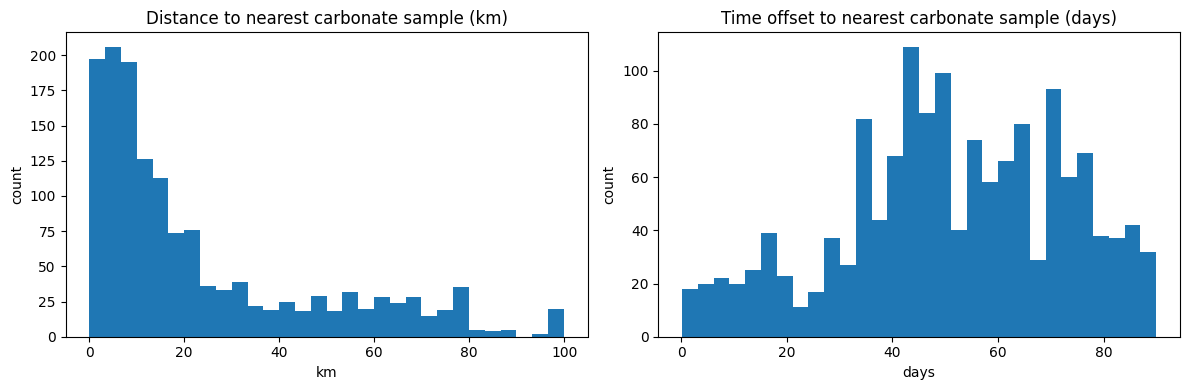

In [27]:
matched = enriched[enriched["carbonate_match_found"] == 1]

if len(matched):
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    ax[0].hist(matched["match_distance_km"].dropna(), bins=30)
    ax[0].set_title("Distance to nearest carbonate sample (km)")
    ax[0].set_xlabel("km")
    ax[0].set_ylabel("count")

    ax[1].hist(matched["match_delta_days"].dropna(), bins=30)
    ax[1].set_title("Time offset to nearest carbonate sample (days)")
    ax[1].set_xlabel("days")
    ax[1].set_ylabel("count")
    plt.tight_layout()
    plt.show()


In [28]:
TARGET_REG = "Percent_Bleaching"

data = enriched.copy().replace("nd", np.nan)
data["Year"] = data["Date"].dt.year
data["Month"] = data["Date"].dt.month

reg_all = data.dropna(subset=[TARGET_REG]).copy()
reg_matched = reg_all[reg_all["carbonate_match_found"] == 1].copy()

drop_text = [c for c in reg_matched.columns if "Comments" in c] + ["Site_Comments", "Sample_Comments", "Bleaching_Comments"]
drop_text = [c for c in drop_text if c in reg_matched.columns]

id_like_cols = {
    c for c in reg_matched.columns
    if c.lower().startswith("unnamed")
    or c.lower().endswith("_id")
    or c.lower() == "id"
}
leakage_like_cols = {"Bleaching_Level"}
exclude_common = set([TARGET_REG, "Date", "bleach_row_id", "match_year"]) | set(drop_text) | id_like_cols | leakage_like_cols
baseline_exclude = exclude_common | set(carbonate_feature_cols + ["carbonate_match_found", "match_distance_km", "match_delta_days"])
enriched_exclude = exclude_common

baseline_features = [c for c in reg_matched.columns if c not in baseline_exclude]
enriched_features = [c for c in reg_matched.columns if c not in enriched_exclude]


def normalize_mixed_types(df, columns):
    out = df.copy()
    for col in columns:
        if out[col].dtype == "object":
            numeric_try = pd.to_numeric(out[col], errors="coerce")
            if numeric_try.notna().mean() >= 0.9:
                out[col] = numeric_try
            else:
                out[col] = out[col].astype("string")
    return out


reg_matched = normalize_mixed_types(reg_matched, list(set(baseline_features + enriched_features)))

print("Rows available for model comparison:", len(reg_matched))
print("Dropped leakage/ID columns:", sorted(id_like_cols | leakage_like_cols))
print("Baseline feature count:", len(baseline_features))
print("Enriched feature count:", len(enriched_features))


Rows available for model comparison: 1463
Dropped leakage/ID columns: ['Bleaching_Level', 'Unnamed: 0', 'bleach_row_id']
Baseline feature count: 43
Enriched feature count: 54


In [29]:
models = {
    "LinearRegression": LinearRegression(),
    "Ridge": Ridge(alpha=1.0),
    "RandomForestRegressor": RandomForestRegressor(
        n_estimators=400,
        random_state=42,
        n_jobs=-1,
        min_samples_leaf=2,
    ),
}


def run_regression_experiment(df, feature_cols, label):
    work = df.dropna(subset=[TARGET_REG]).copy()
    if len(work) < 100:
        print(f"{label}: not enough rows for stable train/test split.")
        return pd.DataFrame(), None, None, None

    x = work[feature_cols]
    y = work[TARGET_REG]

    cat_cols = [c for c in feature_cols if not pd.api.types.is_numeric_dtype(work[c])]
    num_cols = [c for c in feature_cols if c not in cat_cols]

    group_key = (
        work["Latitude_Degrees"].round(3).astype("string")
        + "|"
        + work["Longitude_Degrees"].round(3).astype("string")
        + "|"
        + work["Year"].astype("Int64").astype("string")
        + "|"
        + work["Month"].astype("Int64").astype("string")
    )
    if group_key.nunique(dropna=False) >= 2:
        splitter = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
        train_idx, test_idx = next(splitter.split(x, y, groups=group_key))
        x_train, x_test = x.iloc[train_idx], x.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    else:
        x_train, x_test, y_train, y_test = train_test_split(
            x, y, test_size=0.2, random_state=42
        )

    preprocess = ColumnTransformer(
        transformers=[
            ("num", Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler()),
            ]), num_cols),
            ("cat", Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", OneHotEncoder(handle_unknown="ignore")),
            ]), cat_cols),
        ],
        remainder="drop",
    )

    rows = []
    best_name = None
    best_rmse = np.inf
    best_pred = None

    for name, model in models.items():
        pipe = Pipeline([("preprocess", preprocess), ("model", model)])
        pipe.fit(x_train, y_train)
        pred = pipe.predict(x_test)

        mae = mean_absolute_error(y_test, pred)
        rmse = mean_squared_error(y_test, pred) ** 0.5
        r2 = r2_score(y_test, pred)
        rows.append((label, name, mae, rmse, r2))

        if rmse < best_rmse:
            best_rmse = rmse
            best_name = name
            best_pred = (y_test, pred)

    result = pd.DataFrame(rows, columns=["dataset", "model", "MAE", "RMSE", "R2"]).sort_values(["dataset", "RMSE"])
    return result, best_name, best_pred[0], best_pred[1]


In [30]:
baseline_results, baseline_best, baseline_y_test, baseline_pred = run_regression_experiment(
    reg_matched,
    baseline_features,
    label="baseline_matched_rows",
)
enriched_results, enriched_best, enriched_y_test, enriched_pred = run_regression_experiment(
    reg_matched,
    enriched_features,
    label="carbonate_enriched_matched_rows",
)

comparison = pd.concat([baseline_results, enriched_results], ignore_index=True)
comparison.sort_values(["dataset", "RMSE"])


,dataset,model,MAE,RMSE,R2
0,baseline_matched_rows,RandomForestRegressor,6.929359,9.822822,0.714050
1,baseline_matched_rows,Ridge,9.659556,13.541448,0.456564
2,baseline_matched_rows,LinearRegression,9.790524,13.877476,0.429259
3,carbonate_enriched_matched_rows,RandomForestRegressor,7.081366,9.763543,0.717490
4,carbonate_enriched_matched_rows,Ridge,9.570732,13.280362,0.477317
5,carbonate_enriched_matched_rows,LinearRegression,9.782800,13.650815,0.447750


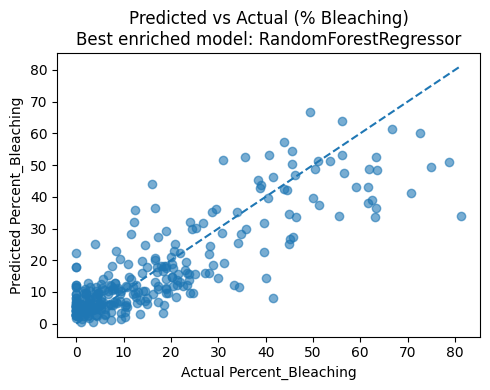

In [31]:
if enriched_best is not None:
    plt.figure(figsize=(5, 4))
    plt.scatter(enriched_y_test, enriched_pred, alpha=0.6)
    plt.title(f"Predicted vs Actual (% Bleaching)\nBest enriched model: {enriched_best}")
    plt.xlabel("Actual Percent_Bleaching")
    plt.ylabel("Predicted Percent_Bleaching")
    mn = min(enriched_y_test.min(), np.min(enriched_pred))
    mx = max(enriched_y_test.max(), np.max(enriched_pred))
    plt.plot([mn, mx], [mn, mx], linestyle="--")
    plt.tight_layout()
    plt.show()


In [32]:
corr_cols = [c for c in carbonate_feature_cols if c in reg_matched.columns]
corr_df = reg_matched[corr_cols + [TARGET_REG]].apply(pd.to_numeric, errors="coerce")
carbonate_corr = corr_df.corr(numeric_only=True)[TARGET_REG].drop(TARGET_REG).sort_values(key=lambda s: s.abs(), ascending=False)
carbonate_corr


Salinity_Bottle                           -0.059145
Aragonite_Saturation_State                 0.026594
pCO2                                      -0.025040
Temperature_C                              0.017601
Total_Alkalinity_MICRO_MOL_KG              0.008120
pH_calculated                              0.001003
Dissolved_Inorganic_Carbon_MICRO_MOL_KG    0.000646
pH_measured                                     NaN
Name: Percent_Bleaching, dtype: float64

In [37]:
# Random Forest feature importance on enriched feature set (group-aware split)
rf_feature_set = enriched_features
work = reg_matched.dropna(subset=[TARGET_REG]).copy()

if len(work) < 100:
    print("Not enough rows for stable feature-importance fit.")
else:
    x = work[rf_feature_set]
    y = work[TARGET_REG]

    cat_cols = [c for c in rf_feature_set if not pd.api.types.is_numeric_dtype(work[c])]
    num_cols = [c for c in rf_feature_set if c not in cat_cols]

    group_key = (
        work["Latitude_Degrees"].round(3).astype("string")
        + "|"
        + work["Longitude_Degrees"].round(3).astype("string")
        + "|"
        + work["Year"].astype("Int64").astype("string")
        + "|"
        + work["Month"].astype("Int64").astype("string")
    )
    if group_key.nunique(dropna=False) >= 2:
        splitter = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
        train_idx, test_idx = next(splitter.split(x, y, groups=group_key))
        x_train, x_test = x.iloc[train_idx], x.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    else:
        x_train, x_test, y_train, y_test = train_test_split(
            x, y, test_size=0.2, random_state=42
        )

    preprocess = ColumnTransformer(
        transformers=[
            ("num", Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler()),
            ]), num_cols),
            ("cat", Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", OneHotEncoder(handle_unknown="ignore")),
            ]), cat_cols),
        ],
        remainder="drop",
    )

    rf = RandomForestRegressor(
        n_estimators=400,
        random_state=42,
        n_jobs=-1,
        min_samples_leaf=2,
    )
    pipe = Pipeline([("preprocess", preprocess), ("model", rf)])
    pipe.fit(x_train, y_train)

    importances = pipe.named_steps["model"].feature_importances_

    # Aggregate one-hot categorical importances back to original column names.
    imp_map = {c: 0.0 for c in rf_feature_set}
    for i, c in enumerate(num_cols):
        imp_map[c] += float(importances[i])

    if cat_cols:
        ohe = pipe.named_steps["preprocess"].named_transformers_["cat"].named_steps["onehot"]
        cat_importances = importances[len(num_cols):]
        cursor = 0
        for col_name, cats in zip(cat_cols, ohe.categories_):
            width = len(cats)
            imp_map[col_name] += float(cat_importances[cursor:cursor + width].sum())
            cursor += width

    rf_importance = pd.Series(imp_map).sort_values(ascending=False)
    print("Top 20 RF feature importances (aggregated to original columns):")
    print(rf_importance.head(20).to_string())

    carbonate_rf_importance = rf_importance.reindex(corr_cols)
    print("\\nCarbonate-only RF feature importances:")
    print(carbonate_rf_importance.sort_values(ascending=False).to_string())


Top 20 RF feature importances (aggregated to original columns):
Year                                       0.362846
TSA_DHW                                    0.123549
Longitude_Degrees                          0.079347
Latitude_Degrees                           0.043180
match_delta_days                           0.042783
Month                                      0.041839
match_distance_km                          0.024943
Depth_m                                    0.017083
Temperature_C                              0.016663
Salinity_Bottle                            0.016658
Aragonite_Saturation_State                 0.014784
Total_Alkalinity_MICRO_MOL_KG              0.014552
pH_calculated                              0.013643
SSTA_Frequency                             0.012314
Dissolved_Inorganic_Carbon_MICRO_MOL_KG    0.011772
pCO2                                       0.011597
Turbidity                                  0.009800
Percent_Cover                              0.008750
